In [ ]:
# pandas: tabular data loading and column access
# matplotlib as mpl: global rcParams for axis tick colors (applied before any plot is created)
# matplotlib.pyplot: figure, axes, and step chart rendering
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Load the shot-level xG dataset for a single match (Southampton vs Bournemouth).
# Each row represents one shot event with: minute, team, xG value, player name, and shot result.
# This is a pre-extracted CSV — not a live StatsBomb API call — so no authentication is needed.
# Columns:
#   minute  — match minute of the shot (integer)
#   team    — team that took the shot
#   xG      — expected goals probability from the xG model (float, 0–1)
#   player  — player who took the shot
#   result  — outcome: Goal, SavedShot, BlockedShot, MissedShots, ShotOnPost
df = pd.read_csv('data/xgtutorial8.csv')

df

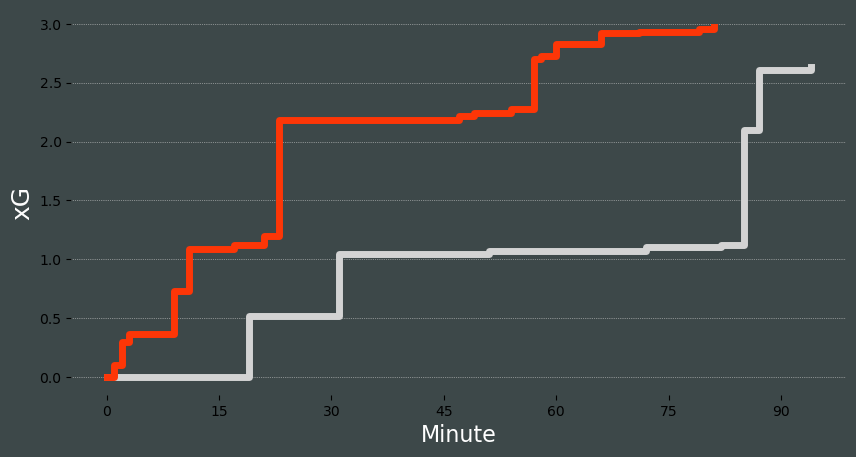

In [2]:
# Build separate xG timelines for each team.
# Both lists are seeded with (0, 0) so the step chart starts at the origin
# and the first shot creates a visible first step from minute 0.
away_xg = [0]
away_min = [0]
home_xg = [0]
home_min = [0]

# Infer team names from the DataFrame: the first row's team is the home team,
# the last row's team is the away team. This assumes the CSV preserves row ordering
# with home shots appearing before away shots — valid for the specific export format used here.
home_team = df['team'].iloc[0]
away_team = df['team'].iloc[-1]

# Separate the xG values and their timestamps per team.
# Each shot's xG and minute are appended to the corresponding team's list.
for x in range(len(df['xG'])):
    if df['team'][x] == away_team:
        away_xg.append(df['xG'][x])
        away_min.append(df['minute'][x])
    if df['team'][x] == home_team:
        home_xg.append(df['xG'][x])
        home_min.append(df['minute'][x])

def nums_calculative_sum(nums_list: list):
    # Computes a running (cumulative) sum of a list.
    # For each index i, the output is the sum of all elements from 0 to i inclusive.
    # This converts a list of individual xG values into a monotonically increasing
    # cumulative xG timeline that grows each time the team creates a chance.
    return [sum(nums_list[:i + 1]) for i in range(len(nums_list))]

away_acumulative = nums_calculative_sum(away_xg)
home_acumulative = nums_calculative_sum(home_xg)

# Round the final cumulative totals for annotation use.
away_last = round(away_acumulative[-1], 2)
home_last = round(home_acumulative[-1], 2)

# --- Step chart: cumulative xG over time ---
fig, ax = plt.subplots(figsize=(10, 5))
fig.set_facecolor('#3d4849')
ax.patch.set_facecolor('#3d4849')

# Set tick and label colors to white for dark background readability.
mpl.rcParams['xtick.color'] = 'white'
mpl.rcParams['ytick.color'] = 'white'

ax.grid(ls='dotted', lw=.5, color='lightgrey', axis='y', zorder=1)

# Remove all four axis spines (border lines) for a cleaner dark-background aesthetic.
for x in ['top', 'bottom', 'left', 'right']:
    ax.spines[x].set_visible(False)

# x-axis ticks at standard match phase boundaries (kickoff, 15, 30, 45, 60, 75, 90).
plt.xticks([0, 15, 30, 45, 60, 75, 90])
plt.xlabel('Minute', color='white', fontsize=16)
plt.ylabel('xG', color='white', fontsize=18)

# ax.step() draws a step function connecting each (minute, cumulative_xG) coordinate.
# where='post' means the line holds its current value and only steps up AFTER the new
# data point — correctly representing that xG accumulates at the moment of each shot,
# not before it. This produces the characteristic staircase shape of xG timelines.
# Southampton: red (#fd3607); Bournemouth: light grey (#d3d3d3).
ax.step(x=away_min, y=away_acumulative, color='#d3d3d3', label=away_team, linewidth=5, where='post')
ax.step(x=home_min, y=home_acumulative, color='#fd3607', label=home_team, linewidth=5, where='post')

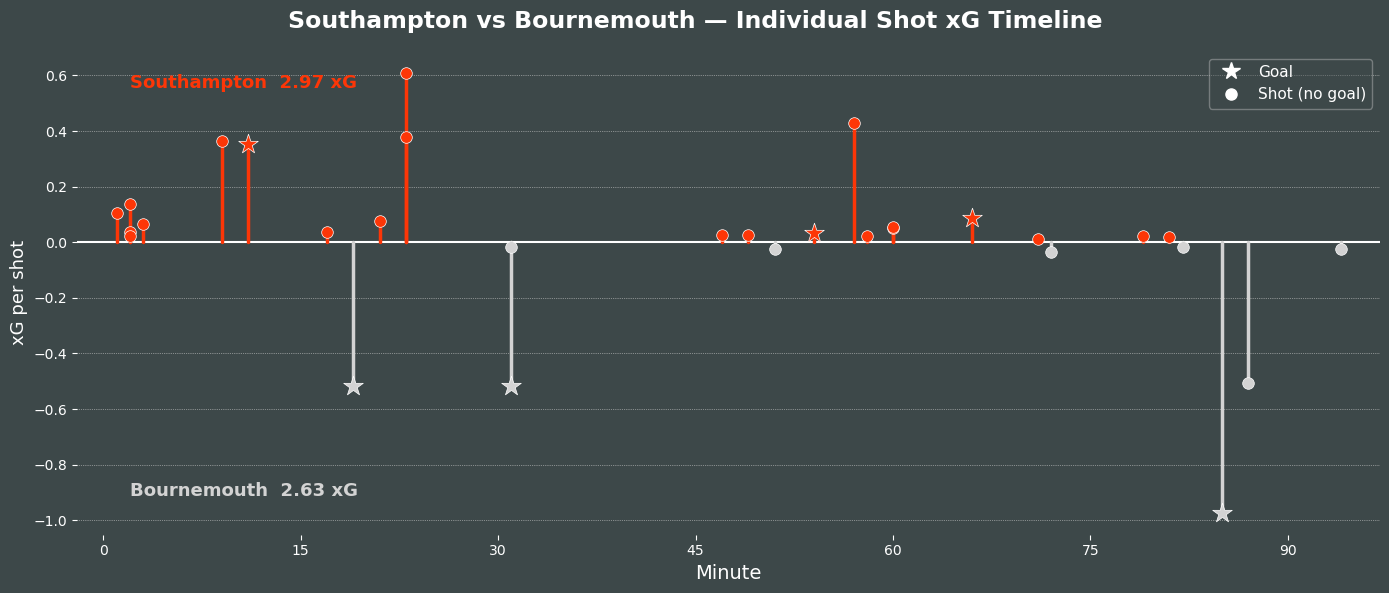

In [3]:
# --- Diverging shot timeline: individual xG per chance, per minute ---
#
# The cumulative step chart above shows the overall xG narrative but hides two things:
#   1. The quality of each individual shot (a 0.01 xG and a 0.6 xG look the same as single steps)
#   2. The temporal clustering of chances within match phases
#
# This diverging timeline addresses both: each shot is drawn as a vertical stem whose
# HEIGHT encodes its xG value. The two teams are plotted on opposite sides of a central
# horizontal axis — home team (Southampton) above, away team (Bournemouth) below.
# Goal shots are marked with a star to distinguish them from non-scoring attempts.
#
# Reading this chart:
#   - Tall stems = high-danger shots (big chances)
#   - Dense clusters = sustained pressure phases
#   - Stars = moments when xG translated into an actual goal
#   - The horizontal gap between a team's stems = periods without any shot attempt
#
# Together with the cumulative chart, this view answers a different question:
# not "who was dominant across the match" but "when were the biggest individual
# moments of danger, and did they result in goals?"

import matplotlib.lines as mlines

home_color = '#fd3607'   # Southampton
away_color = '#d3d3d3'   # Bournemouth

home_df = df[df['team'] == home_team].copy()
away_df = df[df['team'] == away_team].copy()

fig, ax = plt.subplots(figsize=(14, 6))
fig.set_facecolor('#3d4849')
ax.patch.set_facecolor('#3d4849')

mpl.rcParams['xtick.color'] = 'white'
mpl.rcParams['ytick.color'] = 'white'

ax.grid(ls='dotted', lw=0.5, color='lightgrey', axis='y', zorder=1)
for spine in ax.spines.values():
    spine.set_visible(False)

# Central dividing line separating the two teams' shot zones
ax.axhline(0, color='white', linewidth=1.5, zorder=2)

plt.xticks([0, 15, 30, 45, 60, 75, 90])
ax.set_xlim(-2, 97)
ax.set_xlabel('Minute', color='white', fontsize=14)
ax.set_ylabel('xG per shot', color='white', fontsize=13)

# Draw each home team (Southampton) shot as a vertical stem above the axis.
# The stem height equals the shot's xG value.
# Goals use a star marker (s=220); all other shots use a circle (s=70).
for _, row in home_df.iterrows():
    is_goal = row['result'] == 'Goal'
    ax.plot([row['minute'], row['minute']], [0, row['xG']],
            color=home_color, linewidth=2.5, zorder=3, solid_capstyle='round')
    ax.scatter(row['minute'], row['xG'],
               marker='*' if is_goal else 'o',
               s=220 if is_goal else 70,
               color=home_color, edgecolors='white', linewidths=0.5, zorder=4)

# Draw each away team (Bournemouth) shot as a vertical stem below the axis.
# Negative xG values mirror the home team's layout, creating a diverging view.
for _, row in away_df.iterrows():
    is_goal = row['result'] == 'Goal'
    ax.plot([row['minute'], row['minute']], [0, -row['xG']],
            color=away_color, linewidth=2.5, zorder=3, solid_capstyle='round')
    ax.scatter(row['minute'], -row['xG'],
               marker='*' if is_goal else 'o',
               s=220 if is_goal else 70,
               color=away_color, edgecolors='white', linewidths=0.5, zorder=4)

# Team name labels positioned near their respective axis halves, with total xG appended.
ylim = ax.get_ylim()
ax.text(2, ylim[1] * 0.88, f'{home_team}  {home_last} xG',
        color=home_color, fontsize=13, fontweight='bold', va='top')
ax.text(2, ylim[0] * 0.88, f'{away_team}  {away_last} xG',
        color=away_color, fontsize=13, fontweight='bold', va='bottom')

# Legend distinguishing goal markers from non-goal shot markers
leg_goal = mlines.Line2D([], [], color='white', marker='*', markersize=13,
                          label='Goal', linestyle='None')
leg_shot = mlines.Line2D([], [], color='white', marker='o', markersize=8,
                          label='Shot (no goal)', linestyle='None')
ax.legend(handles=[leg_goal, leg_shot],
          facecolor='#3d4849', labelcolor='white', fontsize=11,
          loc='upper right', framealpha=0.4)

fig.suptitle(f'{home_team} vs {away_team} — Individual Shot xG Timeline',
             color='white', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary: xG Match Timeline

### What This Notebook Does

This notebook builds two complementary visualizations of match xG data for Southampton vs Bournemouth, using a pre-extracted shot-level CSV. Together they form a complete xG match report: the cumulative step chart shows the overall balance of attacking threat over time, while the diverging shot timeline shows the distribution, quality, and timing of each individual chance.

### Key Concepts

- **Cumulative xG timeline** (`ax.step(where='post')`): The step function is the standard representation for xG accumulation. `where='post'` is critical — it means the line holds its previous value until after the next shot occurs, correctly showing that xG is gained in discrete jumps at shot moments, not continuously. The final value of each team's cumulative line is the best single-number summary of their attacking performance.
- **`nums_calculative_sum()`**: A manual implementation of a running sum equivalent to `itertools.accumulate()` or `pd.Series.cumsum()`. For each index `i`, it sums all elements from index `0` to `i` inclusive. Applied to the per-shot xG list (seeded with `0`), it produces the monotonically increasing cumulative xG sequence plotted on the step chart.
- **Home/away team inference**: `df['team'].iloc[0]` and `df['team'].iloc[-1]` assume the CSV exports home shots first and away shots last. This convention is fragile — a more robust approach is to identify the two unique teams via `df['team'].unique()` and assign roles from match metadata.
- **Diverging shot timeline**: The supplementary chart plots each shot as a vertical stem at its `minute` position. Stem height = `xG`. Home shots extend upward; away shots extend downward (using `-xG`). This diverging layout enables direct visual comparison of shot quality and timing for both teams on a shared time axis. Goals are encoded with a star marker.
- **`solid_capstyle='round'`**: Rounds the top of each stem line, improving readability at small xG values where the stem is very short and the marker needs to connect cleanly to the line.

### Complementary Reading of the Two Charts

| Cumulative step chart | Diverging shot timeline |
|---|---|
| Shows who was dominant across the match | Shows when each individual chance occurred |
| Final values = total xG per team | Individual stem heights = chance quality |
| Gaps between steps = quiet periods | Sparse regions of the x-axis = periods without shots |
| Cannot distinguish shot quality within a phase | Immediately identifies big chances (tall stems) and goal moments (stars) |

### Data Available

| Object | Description |
|---|---|
| `df` | Full shot-level DataFrame with minute, team, xG, player, result |
| `home_acumulative` / `away_acumulative` | Cumulative xG lists per team, seeded at 0 |
| `home_last` / `away_last` | Rounded total xG per team |
| `home_df` / `away_df` | Per-team shot DataFrames (available after the second cell) |

### Ideas to Extract More Value

- **xG by match phase**: Group shots into 15-minute windows and compute total xG per team per phase. Plot as a grouped bar chart to identify which phases of the match each team dominated — a cleaner answer to "when was each team most dangerous" than reading the step chart manually.
- **xG overperformance tracking**: Compare `result == 'Goal'` count against `home_last` / `away_last` for both teams across a season. A team that consistently scores more goals than their xG suggests strong finishing; one that scores less is converting poorly or relying on low-probability shots.
- **Shot sequence labeling**: Use the `player` column on the diverging timeline to annotate high-xG stems (e.g., shots with xG > 0.35) with the shooter's name, immediately attributing big chances to specific players.
- **Multi-match xG rolling average**: Load shot CSVs across a full season for one team and compute a per-match xG total. Plot as a rolling 5-match average to smooth noise and reveal form trends.
- **Goals vs xG scatter by player**: Group by `player`, compute total xG and count of goals per player, and plot as a scatter. Points above the diagonal are outperforming their expected output; points below are underperforming — a standard player evaluation view in modern football analytics.